# Dataset Extraction
We will use "Natural Disasters Emergency Events Database" from Kaggle https://www.kaggle.com/datasets/mexwell/natural-disasters-emergency-events-database?resource=download 

## Database Information
The EM-DAT - Country Profiles dataset provides aggregated figures for natural disasters in EM-DAT, which is the Emergency Events Database, maintained by the Centre for Research on the Epidemiology of Disasters (CRED). The dataset includes data on the number of disasters, the total number of people affected, the total number of deaths, and economic losses (original value and adjusted) for different disaster subtypes for each country and year. The dataset contains information on natural disasters from around the world.

We will focus on 'Drought', 'Flood', 'Storm', and 'Extreme temperature' disasters in Europe. The interesting columns for us will be the Year, Country, Disaster Type, Total Evnets, and Total Damage (USD, adjusted).

As each row has total losses for multiple occurrences, we will create a new column for Average Loss per Event. For our purposes, we will cap the "Average Loss Per Event" between 100 million and 500 million USDs.

Histogram saved as disaster_events_histogram.png


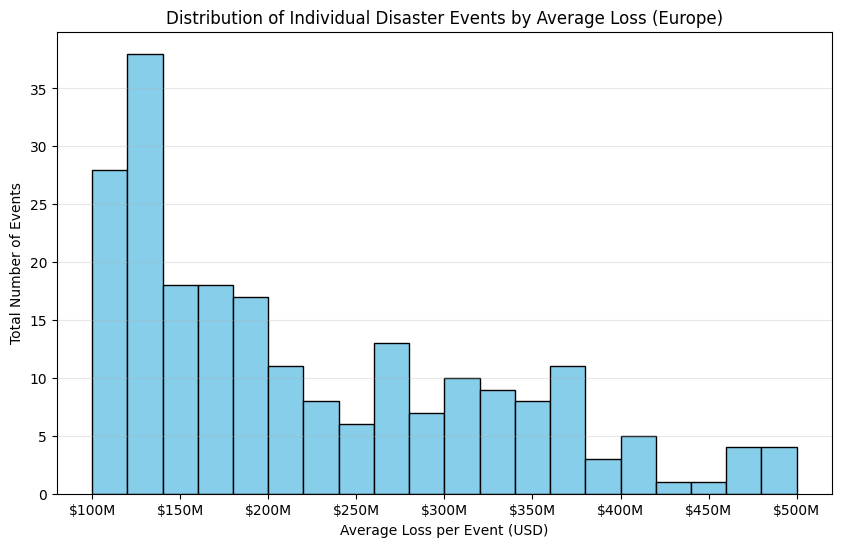

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
# 1. Load and Prepare Data
file_name = '_EmergencyEventsDatabase-CountryProfiles_emdat-country-profiles_2023_04_06.csv'
df = pd.read_csv(file_name, sep=';')

# List of European countries (including historical)
europe_list = [
    'Soviet Union', 'Greece', 'Albania', 'Italy', 'Belgium', 'Romania', 'France', 'Portugal',
    'Germany Fed Rep', 'Bulgaria', 'Poland', 'Norway', 'Spain', 'Yugoslavia', 'Azores Islands',
    'Switzerland', 'Austria', 'United Kingdom of Great Britain and Northern Ireland (the)',
    'Cyprus', 'Canary Is', 'Hungary', 'Iceland', 'Czechoslovakia', 'Denmark', 'Sweden',
    'Ireland', 'Luxembourg', 'Germany Dem Rep', 'Germany', 'Finland', 'Lithuania',
    'Russian Federation (the)', 'Serbia Montenegro', 'Ukraine', 'Belarus',
    'Macedonia (the former Yugoslav Republic of)', 'Moldova (the Republic of)', 'Czech Republic (the)',
    'Croatia', 'Slovakia', 'Slovenia', 'Bosnia and Herzegovina', 'Latvia', 'Estonia',
    'Montenegro', 'Serbia', 'Isle of Man'
]

# 2. Filtering
disaster_list = ['Drought', 'Flood', 'Storm', 'Extreme temperature']
df_europe = df[
    (df['Country'].isin(europe_list)) & 
    (df['Disaster Type'].isin(disaster_list))
].copy()

# 3. Calculations
df_europe['Total Damage (USD, adjusted)'] = pd.to_numeric(df_europe['Total Damage (USD, adjusted)'], errors='coerce')
df_europe['Total Events'] = pd.to_numeric(df_europe['Total Events'], errors='coerce')
df_europe["Year"] = pd.to_numeric(df_europe["Year"], errors='coerce')
df_europe = df_europe.dropna(subset=['Year'])

# Drop rows where we can't calculate average (0 events or no damage data)
df_europe = df_europe.dropna(subset=['Total Damage (USD, adjusted)', 'Total Events'])
df_europe = df_europe[df_europe['Total Events'] > 0]

df_europe['Average Loss per Event'] = df_europe['Total Damage (USD, adjusted)'] / df_europe['Total Events']
df_europe = df_europe[ 
    (df_europe['Average Loss per Event'] > 100_000_000) & (df_europe['Average Loss per Event'] < 500_000_000)
].copy()
# 4. Generate Weighted Histogram
plt.figure(figsize=(10, 6))

# We use the 'weights' parameter to account for 'Total Events'
# We focus on the range under 1 Billion for better visibility, or remove range to see all
plt.hist(
    df_europe['Average Loss per Event'], 
    weights=df_europe['Total Events'], 
    bins=20, 
    range=(100_000_000, 500_000_000),
    color='skyblue', 
    edgecolor='black'
)

plt.title('Distribution of Individual Disaster Events by Average Loss (Europe)')
plt.xlabel('Average Loss per Event (USD)')
plt.ylabel('Total Number of Events')
plt.grid(axis='y', alpha=0.3)

# Format x-axis for readability (Millions)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.0f}M'))

plt.savefig('disaster_events_histogram.png')
print("Histogram saved as disaster_events_histogram.png")

Now that we have extracted the relevant samples, we will generate a probability density function for an event between x and x+dx loss in USD to occur in a given year. The dataset spans years from 1900 to 2022.

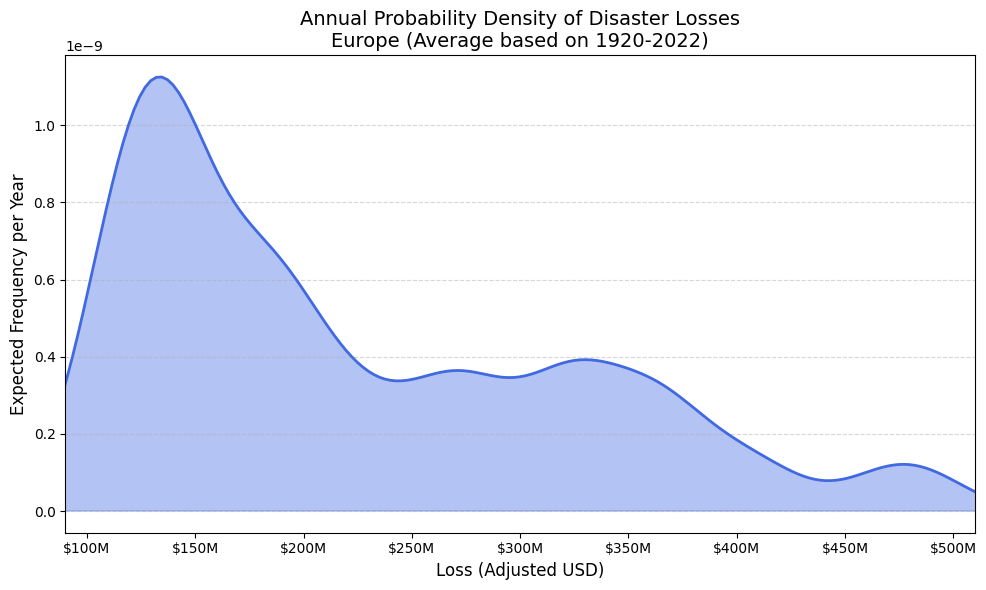

Sample Space: 123 years
Annual Event Rate: 1.79 events/year


In [ ]:
# 1. Define the timeframe
total_years = 2022 - 1900 + 1

# 2. Calculate the total number of events in the whole sample
total_events = df_europe['Total Events'].sum()

# 3. Calculate the Average Annual Rate (lambda)
# This tells us how many disasters happen in Europe per year on average
annual_event_rate = total_events / total_years

# 4. Generate the Plot
plt.figure(figsize=(10, 6))

# We get the KDE data points to manually scale them by the annual rate
ax = sns.kdeplot(
    data=df_europe, 
    x='Average Loss per Event', 
    weights='Total Events', 
    bw_adjust=0.5
)

# Extract the lines from the KDE plot to rescale the Y-axis
line = ax.lines[0]
x_data = line.get_xdata()
y_data = line.get_ydata()

# SCALE the Y-axis: Density * Annual Rate
# This changes the interpretation from "Prob(Loss | Event)" to "Prob(Loss occurring in a Year)"
y_scaled = y_data * annual_event_rate / 10

plt.close() # Close previous to clean up

# 5. Final Plotting
plt.figure(figsize=(10, 6))
plt.fill_between(x_data, y_scaled, color='royalblue', alpha=0.4)
plt.plot(x_data, y_scaled, color='royalblue', lw=2)

plt.title(f'Annual Probability Density of Disaster Losses\nEurope (Average based on 1920-2022)', fontsize=14)
plt.xlabel('Loss (Adjusted USD)', fontsize=12)
plt.ylabel('Expected Frequency per Year', fontsize=12) 

# Format X-axis and limit
plt.xlim(0.9e8, 5.1e8)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.0f}M'))

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Sample Space: {total_years} years")
print(f"Annual Event Rate: {annual_event_rate:.2f} events/year")

As you can see, the annual event rate is approximately 1.79. We can extract our numpy arrays in the last step and validate this finding.

In [3]:
line = ax.lines[0]
x_axis = line.get_xdata()    # Magnitudes (Loss x)
y_density = line.get_ydata() # Probability density f(x)

x_final = np.array(x_axis)
y_final_per_year = y_scaled

np.savez('kde_data.npz', x_final=x_final, y_final_per_year=y_final_per_year)
print("KDE data saved to kde_data.npz")

KDE data saved to kde_data.npz


In [4]:
np.sum(y_final_per_year) * (x_final[1] - x_final[0]) # Should be close to annual_event_rate

np.float64(0.17884986673800934)

In [2]:
def brute_force(r_values, expected_loss, premiums, total_budget):
    N = r_values.shape[1]
    
    # 1. Generate all 2^N - 1 combinations
    numbers = np.arange(1, 2**N, dtype=np.uint32)
    combinations = ((numbers[:, None] & (1 << np.arange(N)[::-1])) > 0).astype(int).T
    
    # 2. Calculate total profit and total cost for EVERY combination
    all_profits = np.dot(r_values, combinations).flatten() - expected_loss
    all_costs = np.dot(premiums, combinations).flatten()
    
    # 3. Filter combinations that are over budget
    valid_mask = all_costs <= total_budget
    
    if not np.any(valid_mask):
        return None, "No valid combination within budget", 0
    
    # 4. Find the combination with the highest profit
    best_relative_idx = np.argmax(all_profits[valid_mask])
    original_idx = np.where(valid_mask)[0][best_relative_idx]
    
    best_combination = combinations[:, original_idx]
    best_profit = all_profits[original_idx]
    best_cost = all_costs[original_idx]
    
    # Identify which project indices were chosen (1-based for readability)
    chosen_projects = np.where(best_combination == 1)[0]
    
    print(f"--- Optimization Result ---")
    print(f"Projects Selected: {chosen_projects}")
    print(f"Total Profit: {best_profit:.2f}")
    print(f"Budget Used: {best_cost:.2f} / {total_budget}")
    print(f"Remaining Budget: {total_budget - best_cost:.2f}")
    
    return best_combination, best_profit

In [37]:
import numpy as np
from generate_N import generate_N
N = 12
thresholds = np.random.uniform(2e8, 5e8, size=N)
props = np.random.uniform(0.5, 1.0, size=N)  # Random proportions for premiums
premiums = np.random.uniform(1e6, 2e6, size=N)  # Random premiums between 1M and 10M
total_budget = 10e6
r_values, expected_loss = generate_N(N, props, thresholds, premiums)
brute_force(r_values, expected_loss, premiums, total_budget)

--- Optimization Result ---
Projects Selected: [ 0  1  5  7  9 10 11]
Total Profit: 193080716.62
Budget Used: 9971443.95 / 10000000.0
Remaining Budget: 28556.05


(array([1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1]), np.float64(193080716.61516276))